In [1]:
%pip install xgboost --quiet

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv('himalayan_glof_data.csv')

print("Dataset Preview:")
print(df.head())

print("\nMissing values check:")
print(df.isnull().sum())

Note: you may need to restart the kernel to use updated packages.
Dataset Preview:
   Lake_Area_km2  Dam_Slope_deg  Lake_Temp_C  Elevation_m  Risk_Index
0         0.4932          12.85         3.15      5120.64      0.4413
1         1.2364          12.41         4.43      3930.97      0.6651
2         0.9543          32.19         4.18      5680.99      0.8088
3         0.7823          12.49         0.85      5032.79      0.4400
4         0.2113          13.16         0.82      3893.01      0.2234

Missing values check:
Lake_Area_km2    0
Dam_Slope_deg    0
Lake_Temp_C      0
Elevation_m      0
Risk_Index       0
dtype: int64


In [2]:
glof_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective='reg:squarederror',
    random_state=42
)

glof_model.fit(X_train, y_train)

print("XGBoost Model Training Complete!")

NameError: name 'X_train' is not defined

In [ ]:
y_pred = glof_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("--- Model Performance Metrics ---")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

comparison_df = pd.DataFrame({'Actual_Risk': y_test, 'Predicted_Risk': y_pred})
print("\nActual vs. Predicted Risk (Sample):")
print(comparison_df.head())

--- Model Performance Metrics ---
R-squared (R2) Score: 0.9920
Mean Squared Error (MSE): 0.0002
Root Mean Squared Error (RMSE): 0.0136

Actual vs. Predicted Risk (Sample):
      Actual_Risk  Predicted_Risk
1860       0.6600        0.657796
353        0.5838        0.575174
1333       0.6041        0.596620
905        0.4519        0.455247
1289       0.3577        0.354188


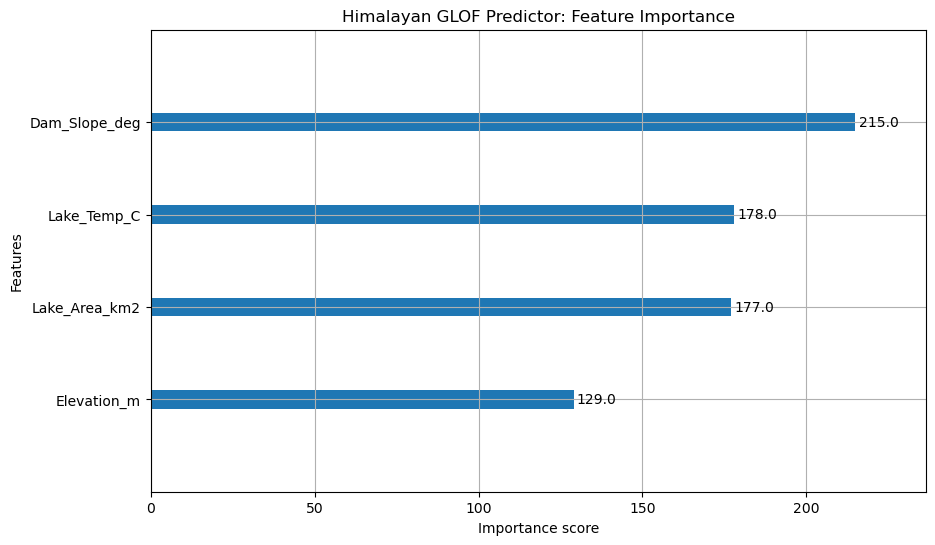

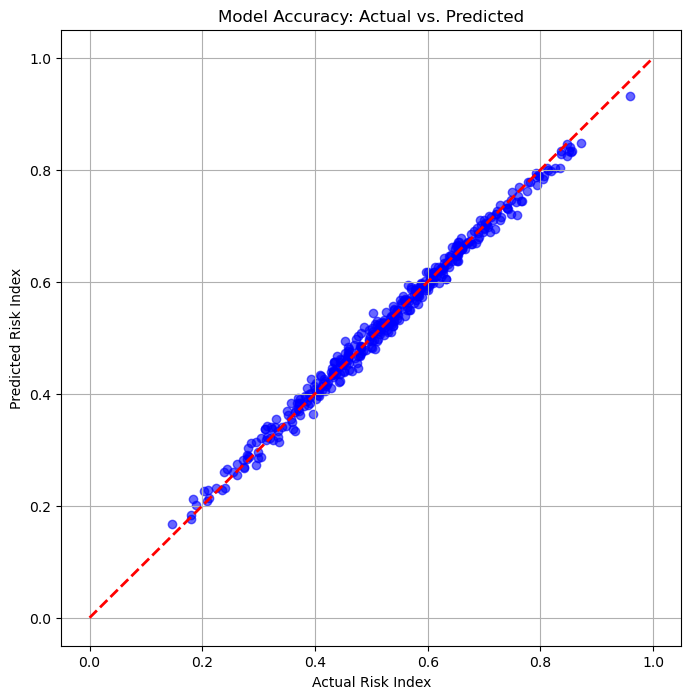

Predicted GLOF Risk: 0.7225


In [ ]:
# Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(glof_model, importance_type='weight', ax=plt.gca())
plt.title('Himalayan GLOF Predictor: Feature Importance')
plt.show()

# Actual vs. Predicted values
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.6, color='b')
plt.plot([0, 1], [0, 1], 'r--', lw=2)  
plt.xlabel('Actual Risk Index')
plt.ylabel('Predicted Risk Index')
plt.title('Model Accuracy: Actual vs. Predicted')
plt.grid(True)
plt.show()

# to test a custom lake
def predict_lake_risk(area, slope, temp, elevation):
    sample = pd.DataFrame([[area, slope, temp, elevation]], 
                          columns=X.columns)
    prediction = glof_model.predict(sample)[0]
    return f"Predicted GLOF Risk: {prediction:.4f}"

# Example Test 
print(predict_lake_risk(0.9, 28.0, 4.5, 5200))

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = glof_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R2 Score: {r2:.5f}")
print(f"Mean Absolute Error: {mae:.5f}")
print(f"Mean Squared Error: {mse:.5f}")

train_preds = glof_model.predict(X_train)
train_r2 = r2_score(y_train, train_preds)
print(f"\nTraining R2: {train_r2:.5f}")
print(f"Testing R2: {r2:.5f}")

R2 Score: 0.99203
Mean Absolute Error: 0.01081
Mean Squared Error: 0.00019

Training R2: 0.99679
Testing R2: 0.99203
